# От Петербурга до Парижа: мемуары человека Серебряного века в цифрах

## Исследовательский вопрос

**«Мои воспоминания» Александра Бенуа** (1870–1960) — это мемуары в пяти томах одного из ключевых деятелей Серебряного века, художника, критика и основателя объединения *«Мир искусства»*. Работа охватывает почти сорок лет — от детства и юности в Санкт-Петербурге до парижских «Русских сезонов». 

Исследовательский вопрос, который был поставлен: можно ли количественными методами проследить, как **меняется мир автора от книги к книге**: его лексика, окружение, география и эмоциональный фон. Гипотеза, которую данные в итоге подтвердили, формулируется как «движение наружу» — от замкнутого пространства семейного дома к космополитическим сценам Европы, и параллельно с этим смена состава действующих лиц: от семьи и прислуги к именам русского и европейского модернизма.

## Цель исследования

Методами количественного анализа выявить, какие характеристики автобиографического текста меняются вместе с биографией автора, а какие остаются неизменной частью его индивидуального стиля, на материале пяти книг мемуаров А. Н. Бенуа.

## Задачи

Для достижения поставленной цели решаются задачи: 
- подготовить и описать корпус (де-вложение глав, очистка, лемматизация); 
- проследить динамику характерной лексики и тематики по книгам (частотный анализ, TF-IDF); 
- восстановить хронологию текста по упоминаниям дат; 
- выявить топонимику и социальные связи (NER, граф совстречаемости); 
- оценить эмоциональную тональность (NRC EmoLex) и грамматический профиль (распределение частей речи); 
- сопоставить переменные и постоянные признаки и дать содержательную интерпретацию.

## Данные

Источник: полный текст «Моих воспоминаний» в пяти книгах, полученный в рамках курса по анализу данных. Корпус оформлен как таблица `benua_books.csv`: пять строк, по одной полной книге, метка книги, объем в словах. Совокупный объем после очистки — около **771 000 слов**, 126 глав.

На этапе подготовки обнаружилась проблема исходного парсинга: текст каждой главы был «вложенным» — содержал не саму главу, а все от ее начала до конца книги. Это диагностировано тем, что текст главы N+1 оказывался дословным «хвостом» текста главы N. Данные восстановлены вычитанием вложенных фрагментов; полный текст каждой книги при этом совпадает с первой ее строкой. Дополнительная очистка регулярными выражениями убрала номера страниц, переносы слов и лишние разрывы строк.

## Методы и инструменты

Обработка и анализ ведутся на Python. 

Используются: 
- регулярные выражения (очистка, детекция иноязычных вставок, извлечение годов);
- `pymorphy3` (лемматизация и определение частей речи); 
- `nltk` (токенизация, стоп-слова);
- `spaCy` (`ru_core_news_sm`, распознавание именованных сущностей — персон и локаций);
-  `scikit-learn` (`TfidfVectorizer`);
- `networkx` (граф связей);
- `pandas`, `matplotlib` и `seaborn` для табличных данных и визуализации. 

Для эмоционального анализа подключён готовый словарь **NRC Emotion Lexicon** (русская версия), размечающий слова по восьми эмоциям.

## 1. Импорты, библиотеки, чтение данных

In [121]:
!pip install pymorphy3 -q
!python -m spacy download ru_core_news_sm -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')


In [122]:
import re
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

import pymorphy3
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy
import networkx as nx

morph = pymorphy3.MorphAnalyzer()
stops = set(stopwords.words('russian'))
nlp = spacy.load('ru_core_news_sm')

df = pd.read_csv('benua_books.csv')
df

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ksenia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ksenia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,книга,слов,символов,полный_текст
0,1,294154,1960411,"Я должен начать свой рассказ с признания, что ..."
1,2,178894,1191730,О театрах и иных зрелищах я до пяти лет имел о...
2,3,75100,501608,Я имею полное основание так озаглавить данную ...
3,4,196672,1324051,Уже через две недели после нашей свадьбы бедна...
4,5,26100,175399,"Свои памятные записки я прервал на том, как в ..."


In [123]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap

PAPER='#F4EFE6'; INK='#733121'; OCHRE="#B19365"; TERRA="#C1826E"; SAGE='#6E7B5B'; SAND='#D8C7A8'
EARTH=[OCHRE, TERRA, SAGE, "#9D742C", "#443117"]
earth_cmap = ListedColormap(EARTH)
museum=LinearSegmentedColormap.from_list('museum', [PAPER, SAND, OCHRE, INK])
mpl.colormaps.register(cmap=museum, name='museum', force=True)



mpl.rcParams.update({
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'savefig.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.titlecolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Serif', 'axes.titlesize': 13, 'figure.dpi': 110,
})

/var/folders/pp/hf1599ns12x1gj0v5xn9fx9c0000gn/T/ipykernel_31988/2167098494.py:9: UserWarning: Overwriting the cmap 'museum' that was already in the registry.
  mpl.colormaps.register(cmap=museum, name='museum', force=True)


## 2. Предобработка

In [124]:
clean = []
for t in df['полный_текст']:
    t = re.sub(r'^\s*[-–—]?\s*\d+\s*[-–—]?\s*$', '', t, flags=re.MULTILINE)
    t = re.sub(r'-\n', '', t)
    t = re.sub(r'(?<!\n)\n(?!\n)', ' ', t)
    clean.append(t)
df['text'] = clean

books_words = {}
for _, row in df.iterrows():
    words = []
    for w in word_tokenize(row['text']):
        if re.match(r'^[а-яё]+$', w.lower()):
            p = morph.parse(w.lower())[0]
            words.append((p.normal_form, p.tag.POS))
    books_words[row['книга']] = words

{k: len(v) for k, v in books_words.items()}

{1: 286030, 2: 173913, 3: 72909, 4: 190293, 5: 25126}

## Базовая статистика

Корпус составляет около 750 тыс. токенов и распределен по книгам неравномерно: от 286 тыс. токенов в первой книге до 25 тыс. в пятой, что требует нормировки показателей при сравнении. Длина предложения стабильна (25–28 слов), а рост сырого TTR от книги к книге отражает не богатство словаря, а уменьшение объема текста.

In [125]:
from nltk.tokenize import sent_tokenize

stats = []
for k in sorted(books_words):
    lemmas = [l for l, _ in books_words[k]]
    n_tokens = len(lemmas)
    n_unique = len(set(lemmas))
    n_sents = len(sent_tokenize(df.loc[df['книга'] == k, 'text'].iloc[0]))
    stats.append({
        'книга': k,
        'токенов': n_tokens,
        'уник. лемм': n_unique,
        'TTR': round(n_unique / n_tokens, 3),
        'предложений': n_sents,
        'слов/предл.': round(n_tokens / n_sents, 1),
    })

stats_df = pd.DataFrame(stats)

total = {
    'книга': 'всего',
    'токенов': stats_df['токенов'].sum(),
    'уник. лемм': len(set(l for k in books_words for l, _ in books_words[k])),
    'TTR': round(len(set(l for k in books_words for l, _ in books_words[k])) / stats_df['токенов'].sum(), 3),
    'предложений': stats_df['предложений'].sum(),
    'слов/предл.': round(stats_df['токенов'].sum() / stats_df['предложений'].sum(), 1),
}
stats_df = pd.concat([stats_df, pd.DataFrame([total])], ignore_index=True)
stats_df

,книга,токенов,уник. лемм,TTR,предложений,слов/предл.
0,1,286030,20098,0.070,10840,26.4
1,2,173913,16223,0.093,6726,25.9
2,3,72909,10047,0.138,2864,25.5
3,4,190293,16311,0.086,6738,28.2
4,5,25126,5390,0.215,925,27.2
5,всего,748271,24896,0.033,28093,26.6


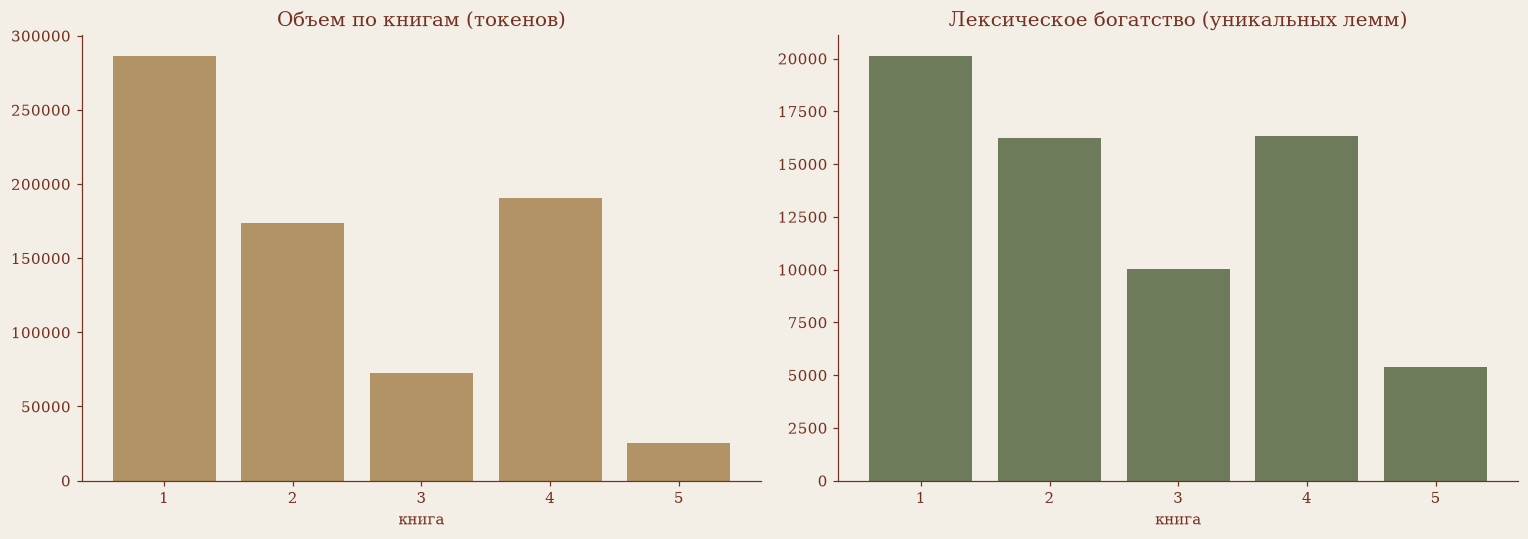

In [126]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

book_rows = stats_df[stats_df['книга'] != 'всего']
ax[0].bar(book_rows['книга'].astype(str), book_rows['токенов'], color=OCHRE)
ax[0].set_title('Объем по книгам (токенов)')
ax[0].set_xlabel('книга')

ax[1].bar(book_rows['книга'].astype(str), book_rows['уник. лемм'], color=SAGE)
ax[1].set_title('Лексическое богатство (уникальных лемм)')
ax[1].set_xlabel('книга')

plt.tight_layout()
plt.show()

## 3. Анализ и визуализации

### Таймлайн

/var/folders/pp/hf1599ns12x1gj0v5xn9fx9c0000gn/T/ipykernel_31988/163313250.py:5: UserWarning: Overwriting the cmap 'museum' that was already in the registry.
  mpl.colormaps.register(cmap=museum, name='museum', force=True)


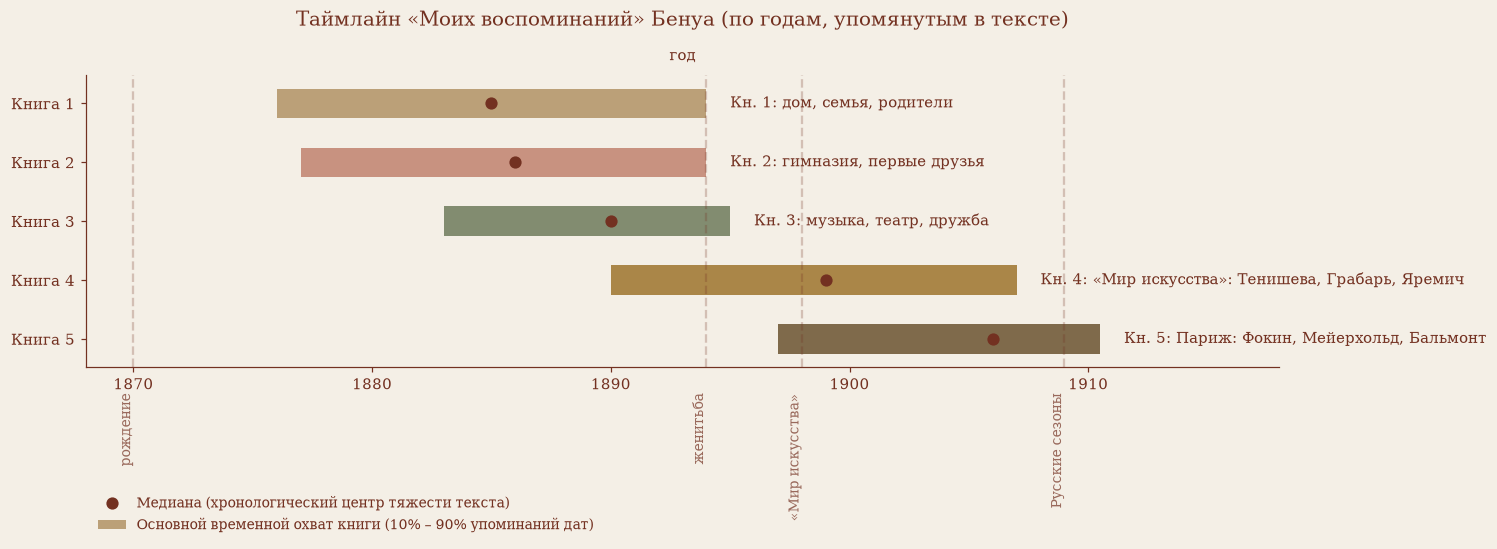

In [127]:
PAPER='#F4EFE6'; INK='#733121'; OCHRE="#B19365"; TERRA="#C1826E"; SAGE='#6E7B5B'; SAND='#D8C7A8'
EARTH=[OCHRE, TERRA, SAGE, "#9D742C", "#6B5330"]
earth_cmap = ListedColormap(EARTH)
museum = LinearSegmentedColormap.from_list('museum', [PAPER, SAND, OCHRE, INK])
mpl.colormaps.register(cmap=museum, name='museum', force=True)

spans = {}
for _, row in df.iterrows():
    ys = [int(y) for y in re.findall(r'\b(18\d\d|19\d\d)\b', row['полный_текст'])]
    ys = [y for y in ys if 1860 <= y <= 1915]
    s = pd.Series(ys)
    spans[row['книга']] = (s.quantile(.1), s.median(), s.quantile(.9))

labels = {
    1: 'дом, семья, родители',
    2: 'гимназия, первые друзья',
    3: 'музыка, театр, дружба',
    4: '«Мир искусства»: Тенишева, Грабарь, Яремич',
    5: 'Париж: Фокин, Мейерхольд, Бальмонт',
}

fig, ax = plt.subplots(figsize=(14, 5))

colors = [EARTH[i % len(EARTH)] for i in range(len(spans))]

box_label_added = False
dot_label_added = False

for (k, (lo, med, hi)), c in zip(sorted(spans.items()), colors):
    b_label = 'Основной временной охват книги (10% – 90% упоминаний дат)' if not box_label_added else ""
    box_label_added = True
    
    ax.barh(k, hi - lo, left=lo, height=0.5, color=c, alpha=0.85, label=b_label)
    
    d_label = 'Медиана (хронологический центр тяжести текста)' if not dot_label_added else ""
    dot_label_added = True
    
    ax.plot(med, k, 'o', color=INK, zorder=3, markersize=7, label=d_label)
    ax.text(hi + 1, k, f'Кн. {k}: {labels[k]}', va='center', fontsize=10, color=INK)

_, y_max = ax.get_ylim()

for yr, name in [(1870, 'рождение'), (1894, 'женитьба'),
                 (1898, '«Мир искусства»'), (1909, 'Русские сезоны')]:
    ax.axvline(yr, ls='--', color=INK, alpha=0.25)
    ax.text(yr, y_max + 0.45, name, rotation=90, fontsize=9, 
            va='top', ha='right', color=INK, alpha=0.7)

ax.set_yticks(list(spans))
ax.set_yticklabels([f'Книга {k}' for k in spans])
ax.invert_yaxis()
ax.set_xlim(1868, 1918)

ax.xaxis.set_label_position('top') 
ax.set_xlabel('год', labelpad=10)
ax.set_title('Таймлайн «Моих воспоминаний» Бенуа (по годам, упомянутым в тексте)', pad=15)


ax.legend(
    loc='upper left', 
    bbox_to_anchor=(0.0, -0.40), 
    frameon=False, 
    fontsize=9, 
    labelcolor=INK
)

plt.subplots_adjust(bottom=0.35) 
plt.show()


Извлечение всех упоминаний годов показало, что медианный год монотонно растет по книгам: 1885 → 1886 → 1890 → 1899 → 1906. Книги 1–3 концентрируются в зоне детства и юности, книги 4–5 уходят в профессиональную карьеру. Это подтверждает, что книги — последовательные этапы жизни, и оправдывает их использование как временной шкалы.

### Топ слов по книгам

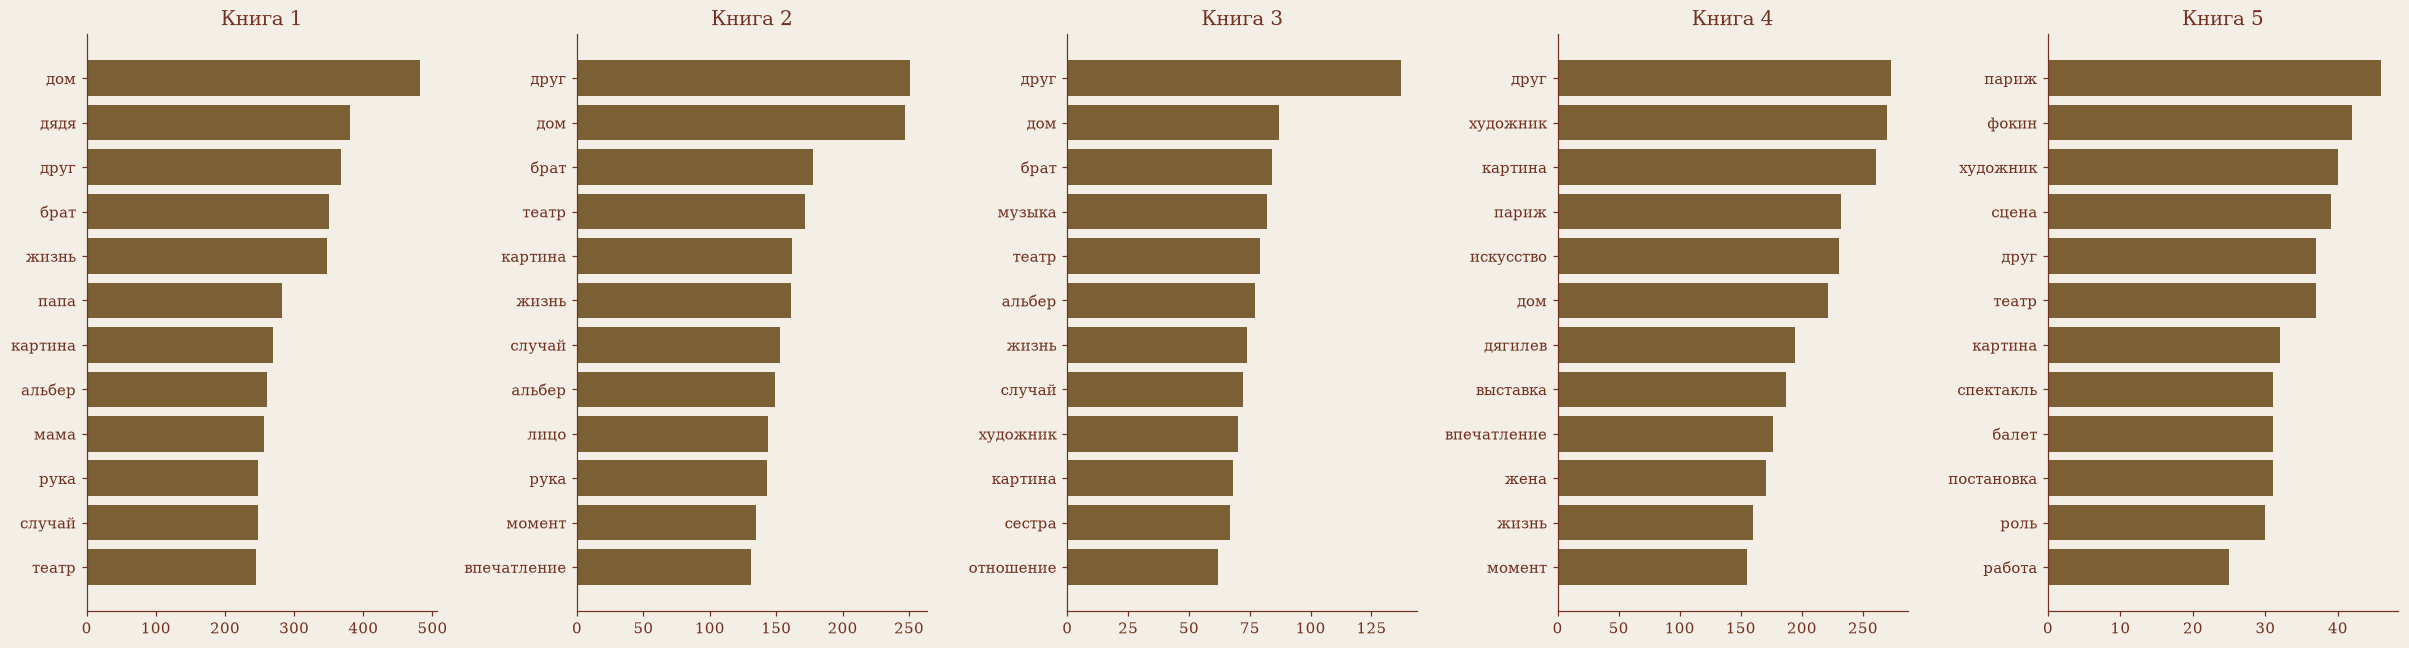

In [128]:
generic = {'год','время','раз','день','вид','место','человек','сторона','дело','часть','образ'}

fig, axes = plt.subplots(1, len(df), figsize=(22, 6))
for ax, k in zip(axes, sorted(books_words)):
    nouns = [l for l, pos in books_words[k] if pos == 'NOUN' and l not in stops and l not in generic]
    top = Counter(nouns).most_common(12)
    words = [w for w, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(words, counts, color="#7C6035")
    ax.set_title(f'Книга {k}')
plt.tight_layout()
plt.show()

Во всех пяти книгах устойчиво присутствуют слова дом, друг, жизнь, брат, картина — лексика семьи, дружбы и искусства, которая сопровождает все повествование. Особо показательно слово «друг»: оно входит в топ каждой книги, а в книгах 3–4 выходит на первое место, что указывает на дружбу как одну из центральных ценностей в мире Бенуа. 

При этом частотный срез фиксирует и тематический сдвиг: если в книгах 1–2 ядро составляют слова домашнего обихода (дом, дядя, папа, мама, брат), то к книгам 4–5 в топ поднимается профессиональная лексика — художник, картина, выставка, сцена, балет, спектакль, постановка. Ограничение метода состоит в том, что частотный список плохо различает книги между собой: общеупотребительные слова доминируют в каждой из них и заслоняют специфику отдельных периодов.

### TF-IDF

существительных в книгах: [70142, 42250, 17541, 46271, 6086]


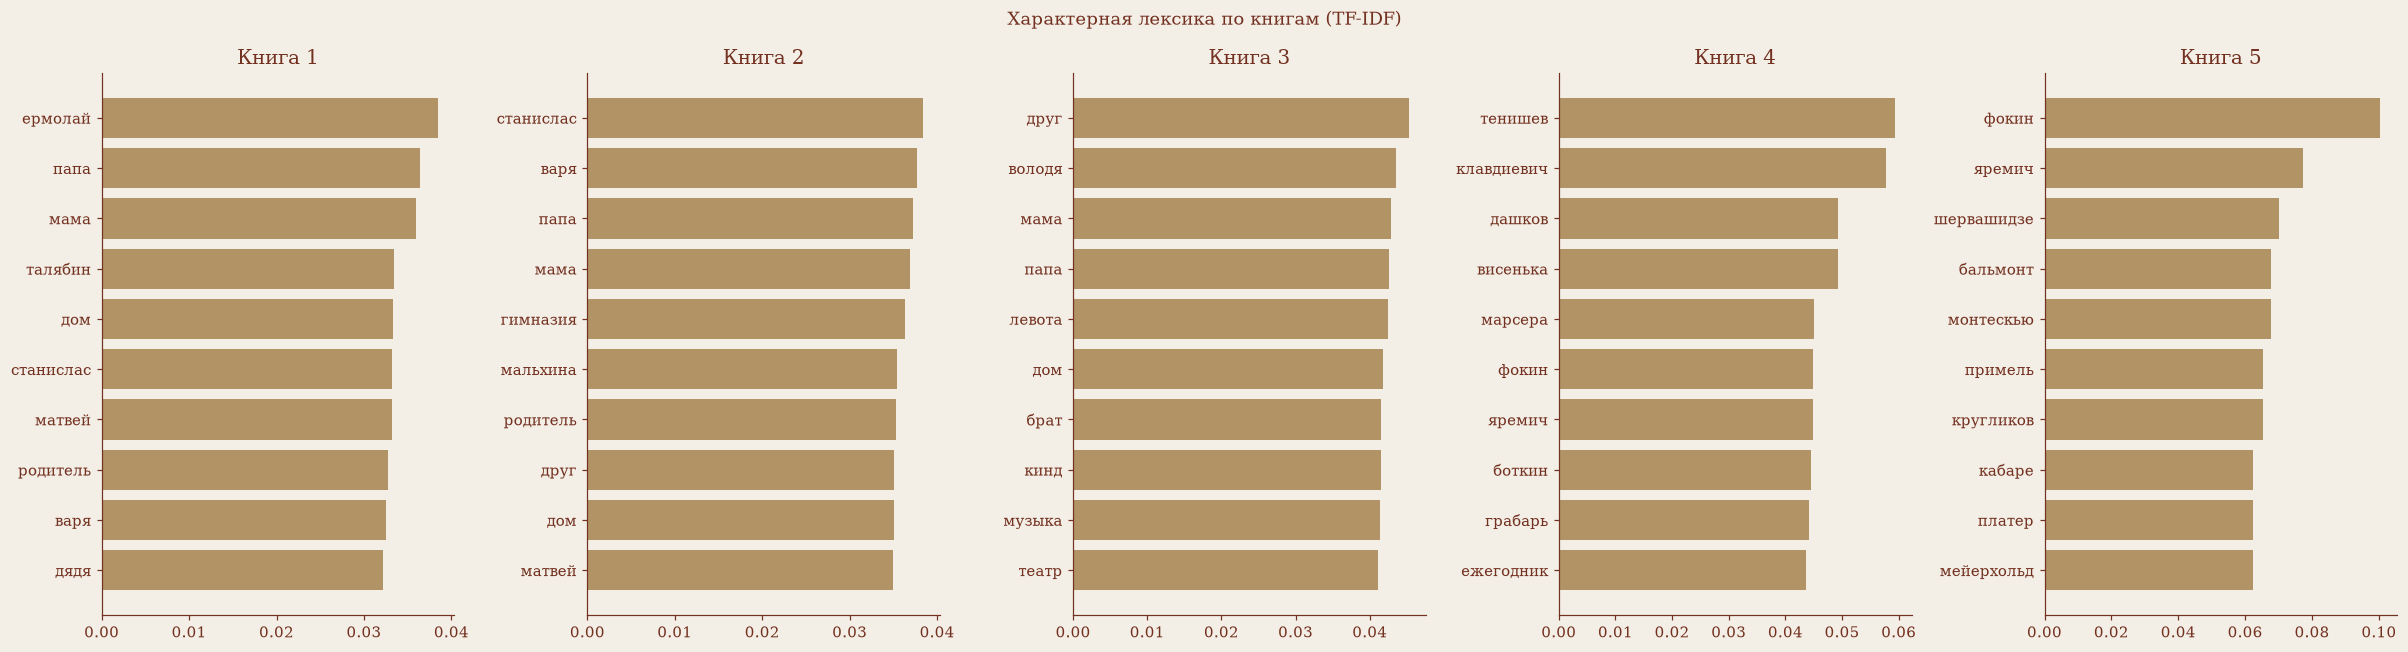

In [129]:
from sklearn.feature_extraction.text import TfidfVectorizer

extra = {'год','время','раз','день','вид','место','человек','сторона','дело','часть','образ'}

docs = []
for k in sorted(df['книга']):
    nouns = []
    for w in word_tokenize(df.loc[df['книга'] == k, 'text'].iloc[0]):
        if re.match(r'^[а-яё]+$', w.lower()):
            p = morph.parse(w.lower())[0]
            if p.tag.POS == 'NOUN' and p.normal_form not in stops and p.normal_form not in extra:
                nouns.append(p.normal_form)
    docs.append(' '.join(nouns))

print('существительных в книгах:', [len(d.split()) for d in docs])  

vec = TfidfVectorizer(max_features=3000, sublinear_tf=True)
X = vec.fit_transform(docs)
terms = vec.get_feature_names_out()

fig, axes = plt.subplots(1, len(docs), figsize=(22, 6))
for ax, k, i in zip(axes, sorted(df['книга']), range(len(docs))):
    scores = X[i].toarray()[0]
    idx = scores.argsort()[::-1][:10]
    ax.barh([terms[j] for j in idx][::-1], [scores[j] for j in idx][::-1], color=OCHRE)
    ax.set_title(f'Книга {k}')
plt.suptitle('Характерная лексика по книгам (TF-IDF)')
plt.tight_layout()
plt.show()

Чтобы выделить не просто частотные, а именно отличительные для каждой книги слова, был применен TF-IDF, повышающий вес слов, частых в одной книге и редких в остальных. Таким образом, получаются совсем другие результаты. Книга 1 характеризуется именами детства и домашнего окружения; книга 2 — лексикой ученичества (гимназия) и первых друзей; в книге 3 впервые появляются «музыка» и «театр» — пробуждение эстетического призвания. Книги 4 и 5 полностью переходят в профессиональный художественный мир: их характерную лексику образуют имена деятелей «Мира искусства» и «Русских сезонов» — Тенишева, Дашков, Яремич, Грабарь, Боткин, ежегодник (книга 4), Фокин, Мейерхольд, Бальмонт, Монтескьё, кабаре (книга 5). Показательно, что отличительной лексикой в большинстве случаев оказываются имена собственные: круг общения служит точнейшим маркером каждого этапа биографии, и «характерные слова» по сути складываются в список действующих лиц соответствующего периода. 

Сопоставление двух метрик отражает разделение на общее и индивидуальное: частотная лексика показывает устойчивое тематическое ядро мемуаров, а TF-IDF проявляет уникальный «отпечаток» каждого периода — последовательное движение от мира семьи к миру европейского искусства.

### Распределение частей речи

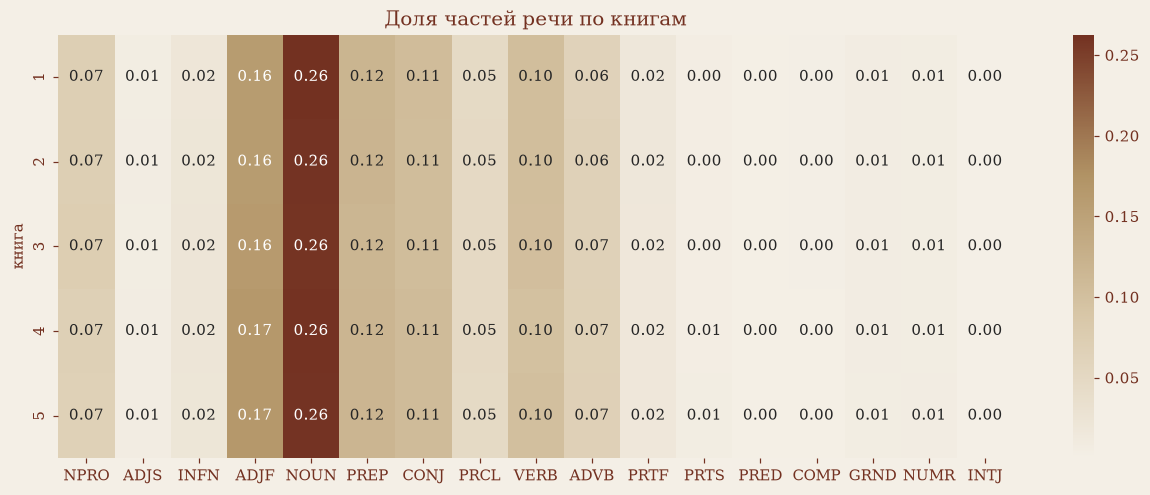

In [130]:
books_pos = {}
for k in books_words:
    books_pos[k] = Counter(pos for _, pos in books_words[k] if pos)

pos_df = pd.DataFrame(books_pos).fillna(0).T
pos_df = pos_df.div(pos_df.sum(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(pos_df, annot=True, fmt='.2f', cmap='museum')
plt.title('Доля частей речи по книгам')
plt.ylabel('книга')
plt.show()

В отличие от лексики, грамматический профиль оказался практически неизменным: во всех пяти книгах доли частей речи совпадают вплоть до сотых. Такое распределение подтверждает устойчивость характеристики индивидуального стиля Бенуа, слабо зависящей от темы.

### Иноязычная лексика по книгам

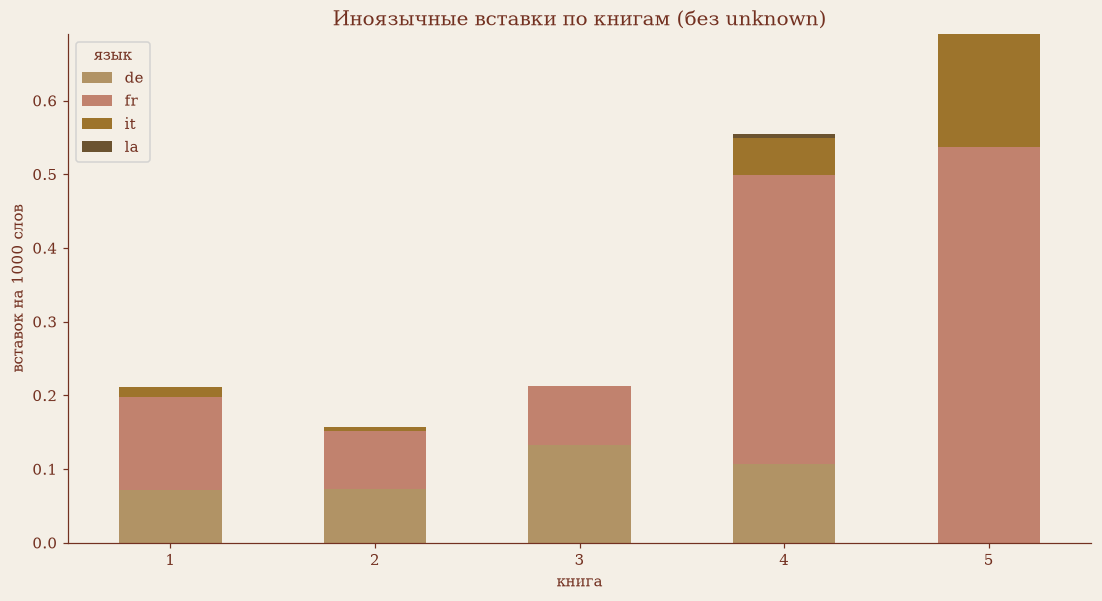

In [131]:
PHRASE = re.compile(r"[A-Za-zÀ-ÿœŒ]+(?:[ \-’'][A-Za-zÀ-ÿœŒ]+)*")

FUNC = {
    'fr': {'le','la','les','un','une','des','du','de','et','est','je','vous','nous',
           'pour','avec','dans','monsieur','madame','très','pas','ne'},
    'de': {'der','die','das','und','ist','nicht','ein','eine','ich','wir','sie',
           'mit','auf','für','über','von','zu','auch','sehr','herr','frau'},
    'it': {'il','lo','la','gli','le','di','che','è','non','per','con','del',
           'della','molto','già','anche','signore','bello'},
    'la': {'et','in','est','non','ad','cum','per','qui','quae','quod','ergo','sub'},
}
DIA = {'fr':'éèêàâçîïôûùœ', 'de':'äöüß', 'it':'àèéìòù', 'la':''}

records = []
for _, row in df.iterrows():
    for m in PHRASE.finditer(row['text']):
        s = m.group()
        if len(s) < 2 or re.match(r'^[IVXLCDM]+$', s):
            continue
        words = re.findall(r"[a-zà-ÿœ']+", s.lower())
        score = {'fr':0, 'de':0, 'it':0, 'la':0}
        for lang in score:
            score[lang] += sum(w in FUNC[lang] for w in words)
            score[lang] += sum(ch in DIA[lang] for ch in s.lower())
        if re.search(r'(sch|ck|ß)', s): score['de'] += 1
        if re.search(r'(zione|gli|gn|etto)', s): score['it'] += 1
        if re.search(r'(eaux|tion|ç)', s): score['fr'] += 1
        best = max(score, key=score.get)
        lang = best if score[best] > 0 else 'unknown'
        records.append({'книга': row['книга'], 'фраза': s, 'язык': lang})

ins = pd.DataFrame(records)

tab = ins[ins['язык'] != 'unknown'].groupby(['книга','язык']).size().unstack(fill_value=0)
tab = tab.div(df.set_index('книга')['слов'], axis=0) * 1000

ax = tab.plot(kind='bar', stacked=True, figsize=(12, 6), cmap=earth_cmap)

plt.ylabel('вставок на 1000 слов')
plt.title('Иноязычные вставки по книгам (без unknown)')
plt.xticks(rotation=0)
plt.show()

Регулярное выражение по латинице нашло около 800 иноязычных вставок. Самая высокая плотность иностранных слов наблюдается в книге 4, так как это период наибольшей светской и художественной активности, погружения в европейскую среду. Французский выступает маркером салонной и художественной речи.

### Эмоциональная тональность по книгам (NRC EmoLex)

In [132]:
import os
print(os.getcwd())
print([f for f in os.listdir() if 'EmoLex' in f or f.endswith('.csv')])

/Users/ksenia/Documents/benua_project
['Russian-NRC-EmoLex.txt', 'benua_books.csv']


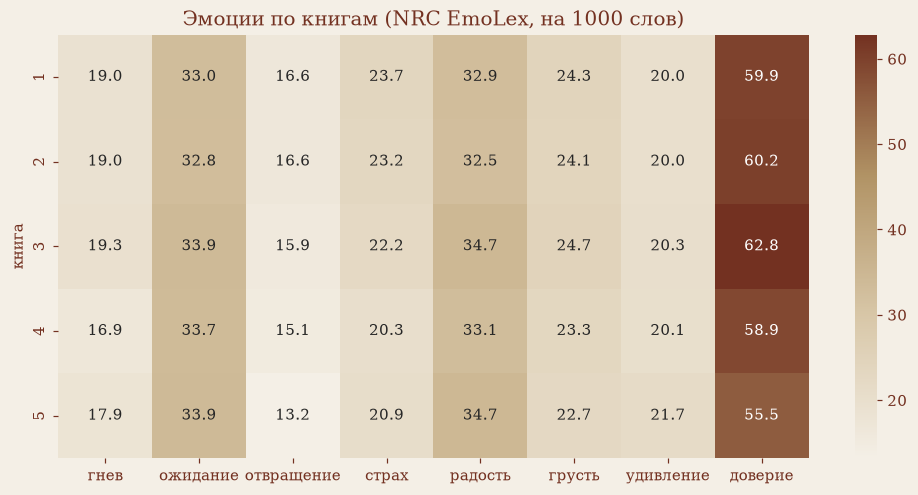

In [133]:
url = './Russian-NRC-EmoLex.txt'
nrc = pd.read_csv(url, sep='\t')

emo_cols = ['anger','anticipation','disgust','fear','joy','sadness','surprise','trust']
emo_ru = {'anger':'гнев','anticipation':'ожидание','disgust':'отвращение','fear':'страх',
          'joy':'радость','sadness':'грусть','surprise':'удивление','trust':'доверие'}

lemmas = []
for w in nrc['Russian Word'].astype(str).str.lower():
    lemmas.append(morph.parse(w)[0].normal_form)
nrc['lemma'] = lemmas

emo_dict = {e: set(nrc.loc[nrc[e] == 1, 'lemma']) for e in emo_cols}

em_tab = pd.DataFrame(0.0, index=sorted(books_words), columns=emo_cols)
for k in books_words:
    c = Counter(l for l, _ in books_words[k])
    total = sum(c.values())
    for e in emo_cols:
        em_tab.loc[k, e] = sum(c[w] for w in emo_dict[e]) / total * 1000
em_tab = em_tab.rename(columns=emo_ru)

plt.figure(figsize=(11, 5))
sns.heatmap(em_tab, annot=True, fmt='.1f', cmap='museum')
plt.title('Эмоции по книгам (NRC EmoLex, на 1000 слов)')
plt.ylabel('книга')
plt.show()

По NRC во всех книгах доминируют доверие, ожидание и радость — тональность скорее светлая, мемуарно-ностальгическая. При этом ранние книги чуть выше по страху и грусти, а поздние — по радости и удивлению, что согласуется с переходом от детских тревог к творческому подъему.

### Упоминания персон и граф связей

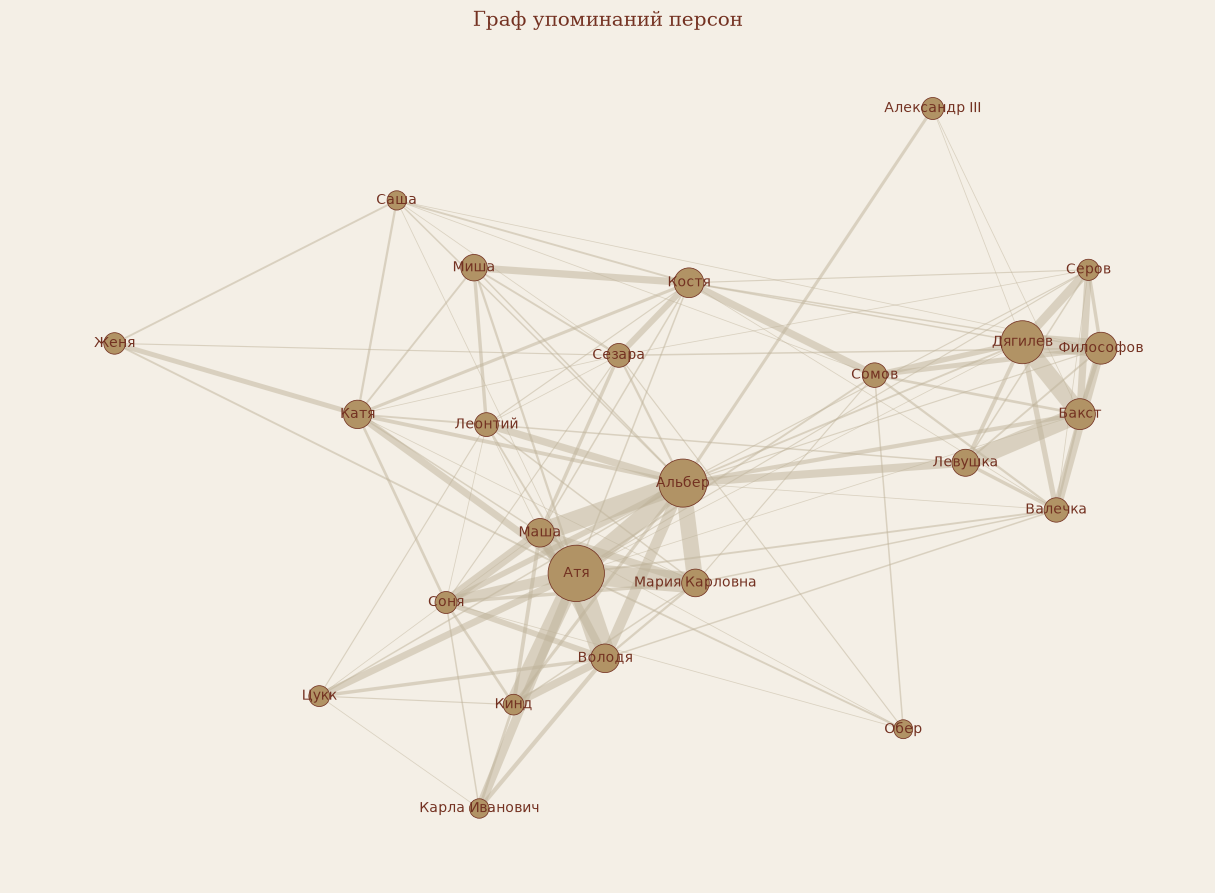

In [134]:
keep = ['tok2vec', 'ner']
disabled = [p for p in nlp.pipe_names if p not in keep]

aliases = {
    'Ати': 'Атя', 'Атю': 'Атя', 'Атея': 'Атя', 'Ата': 'Атя',
    'Серёжа': 'Дягилев',
    'Сомовый': 'Сомов', 'Философовый': 'Философов', 'Дима': 'Философов',
    'Мария Карлович': 'Мария Карловна',
    'Левушко': 'Левушка', 'Левушка': 'Бакст',
    'Кость': 'Костя', 'Косте': 'Костя', 'Костью': 'Костя',
    'Александр Iii': 'Александр III',
}

pairs = Counter()
ent_count = Counter()
W = 1000
for _, row in df.iterrows():
    txt = row['text']
    chunks = [txt[i:i+W] for i in range(0, len(txt), W)]
    for doc in nlp.pipe(chunks, disable=disabled):
        names = set()
        for e in doc.ents:
            if e.label_ == 'PER' and len(e.text.strip()) > 2:
                key = ' '.join(morph.parse(p)[0].normal_form for p in e.text.split()).title()
                key = aliases.get(key, key)
                names.add(key)
        for n in names:
            ent_count[n] += 1 
        for a, b in combinations(sorted(names), 2):
            pairs[(a, b)] += 1


top_names = [n for n, _ in ent_count.most_common(25)]
G = nx.Graph()
for (a, b), w in pairs.items():
    if a in top_names and b in top_names and w >= 2:
        G.add_edge(a, b, weight=w)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.7, seed=1)
sizes = [ent_count[n] * 3 for n in G.nodes()]
widths = [G[u][v]['weight'] * 0.25 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=widths, edge_color='#BFB39A', alpha=0.5)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=OCHRE, edgecolors=INK, linewidths=0.5)

labels = nx.draw_networkx_labels(G, pos, font_size=9, font_color=INK)
    

plt.axis('off')
plt.title('Граф упоминаний персон')
plt.show()

Чтобы реконструировать социальный мир мемуаров, был построен граф совместной встречаемости именованных сущностей. Имена персон извлекались из текста при помощи модели распознавания именованных сущностей `spaCy`. Текст каждой книги разбивался на фрагменты по 1000 символов, и две персоны считались связанными, если упоминались в пределах одного фрагмента; вес ребра равен числу таких совместных упоминаний, а размер узла пропорционален суммарной частоте упоминания персонажа. Извлеченные имена нормализовались: падежные формы приводились к начальной форме (pymorphy3), а вариативные именования и прозвища сводились к единому узлу вручную через словарь соответствий (например, разрозненные падежные варианты прозвища «Атя», а также кореферентные пары вроде «Левушка» — «Бакст»). Для читаемости граф ограничен 25 наиболее упоминаемыми персонами, а ребра с весом меньше 2 отброшены как шум. Расположение узлов задано силовым алгоритмом (spring_layout), в котором сильно связанные вершины притягиваются друг к другу, благодаря чему плотные сообщества образуют визуальные сгущения.

Левый, наиболее плотный кластер — это семейно-домашний мир: его центр и крупнейший узел всего графа — Атя (Анна Карловна — жена художника), вокруг нее группируются Соня, Маша, Катя, Володя, Миша, Женя (родственники, дяди, тети, кузены), а также фигуры детства — Цукк, Кинд, Карл Иванович, Мария Карловна. 

Правый кластер — профессиональный мир «Мира искусства»: Дягилев (крупный узел), Бакст, Серов, Сомов, Философов, Валечка (Валентин Нувель) — ядро художественного объединения и круга «Русских сезонов». Эти два мира соединяет фигура Альбера (старшего брата Бенуа), занимающая центральное положение графа: через нее проходят связи между семьей и художественной средой, что делает Альбера структурным «мостом» между приватным и публичным. Отдельно, почти изолированно, расположен узел Александр III — он упоминается эпизодически и не встроен ни в одно из сообществ.

Граф подтверждает идею двойственной структуры жизни Бенуа и «движению наружу», от узкого семейного круга к расширению художественного мира. Кроме того, вспоминая частоту употребления слова «друг», можно прийти к выводу о том, что Бенуа осмысляет свою жизнь прежде всего через свое окружение. 

**Ограничения метода**

 Совместная встречаемость в фрагменте фиксированной длины — огрубленная мера связи: разбиение по 1000 символов может разрывать сущности на границе фрагментов. Распознавание имен несовершенно (часть прозвищ и фамилий нормализуется неверно и потребовала ручной правки), а обрезка до 25 узлов и порог веса ≥2 отсекают слабые, но потенциально значимые связи. Тем не менее на уровне крупной структуры этот результат устойчив и интерпретируем.

### Топонимика

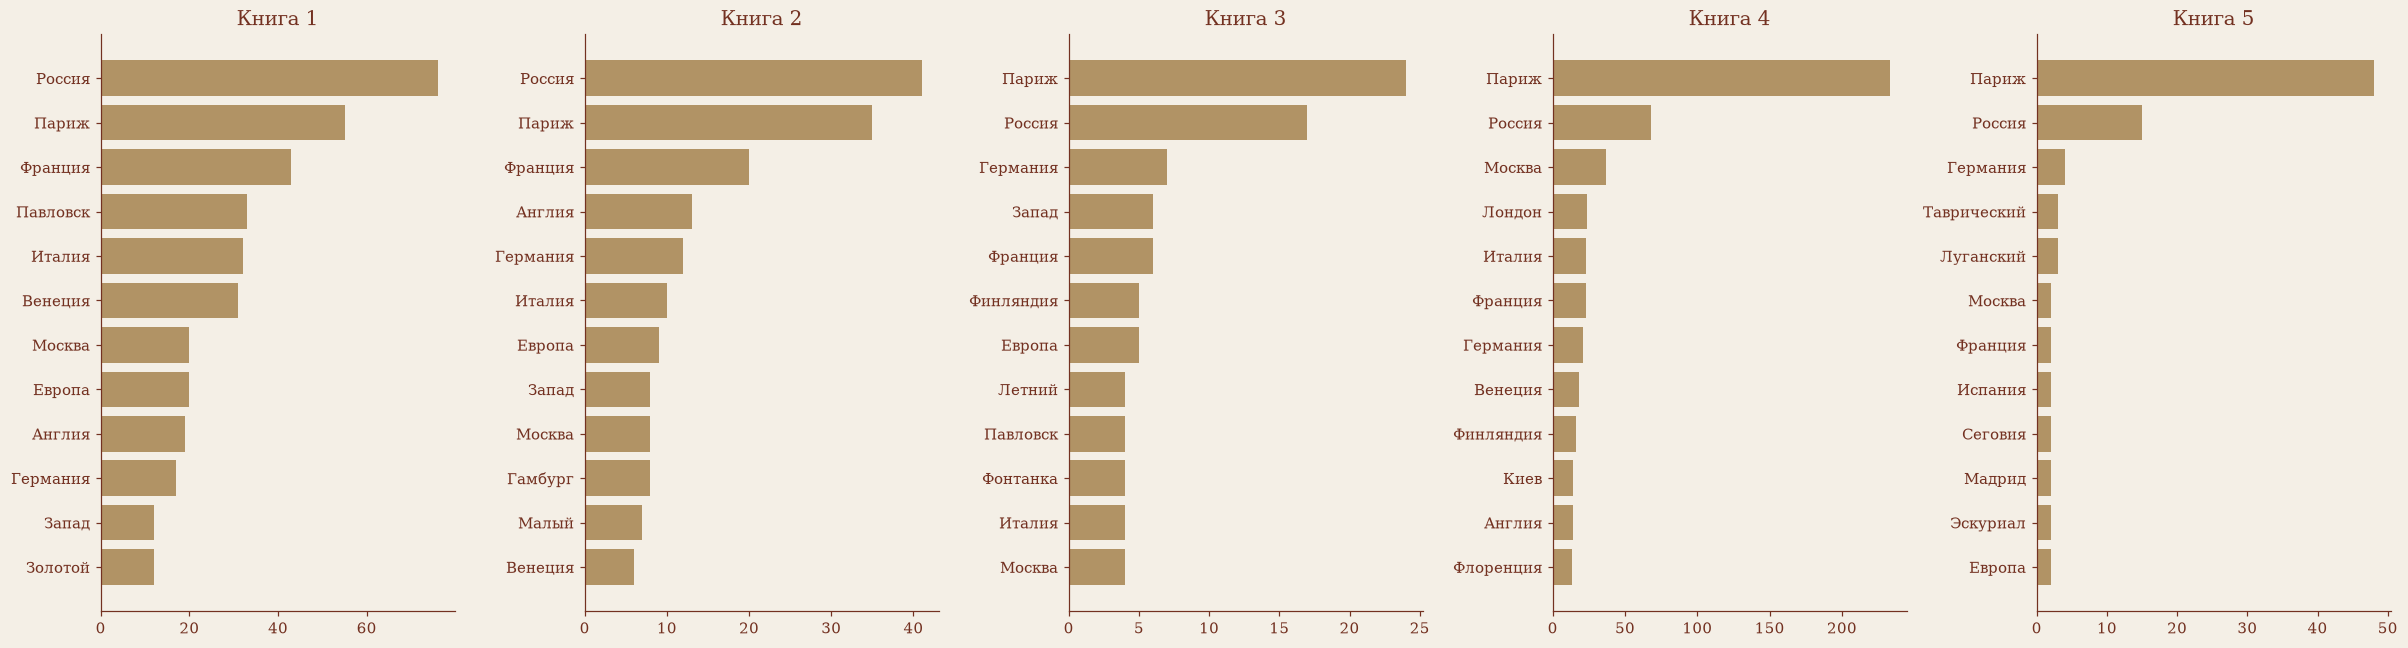

In [135]:
person_names = set(ent_count)
bad_places = {'Кавос', 'Грефюля', 'Локирек', 'Клэхо', 'Хитровый', 'Кость', 'Большой', 'Зимний'}

loc_counts = {k: Counter() for k in books_words}
for _, row in df.iterrows():
    chunks = [row['text'][i:i+1000] for i in range(0, len(row['text']), 1000)]
    for doc in nlp.pipe(chunks, disable=disabled):
        for e in doc.ents:
            if e.label_ == 'LOC' and len(e.text.strip()) > 2:
                place = morph.parse(e.text.split()[0])[0].normal_form.title()
                place = aliases.get(place, place)
                if place not in person_names and place not in bad_places:
                    loc_counts[row['книга']][place] += 1

fig, axes = plt.subplots(1, len(df), figsize=(22, 6))
for ax, k in zip(axes, sorted(loc_counts)):
    top = loc_counts[k].most_common(12)
    ax.barh([p for p, _ in top][::-1], [c for _, c in top][::-1], color=OCHRE)
    ax.set_title(f'Книга {k}')
plt.tight_layout()
plt.show()

Географические названия извлекались распознаванием именованных сущностей (`spaCy`, метка `LOC`), нормализовались по начальной форме и очищались от ложных срабатываний. Распределение мест по книгам наглядно иллюстрирует географическое смещение жизни автора. 

В книгах 1–2 доминирует петербургская орбита: на первом месте Россия и Петербург, рядом — пригородные резиденции Павловск, Петергоф и водные топонимы (Нева). Уже в книге 3 на первое место выходит Париж, а в книгах 4–5 он уверенно лидирует, вокруг него выстраивается европейская география — Версаль, Рим, Лондон, Венеция, Флоренция, Лугано, Бретань. 

Таким образом, физический центр тяжести мемуаров буквально «переезжает» из Петербурга в Париж, что прямо подтверждает магистральную линию исследования — расширение мира автора от родного города к Европе. Ограничение метода состоит в неточности распознавания: модель иногда принимает за топонимы личные имена или выделяет лишь часть составного названия (например, «Таврический» вместо «Таврический дворец», «Зимний» вместо «Зимний дворец»), что потребовало ручной фильтрации.

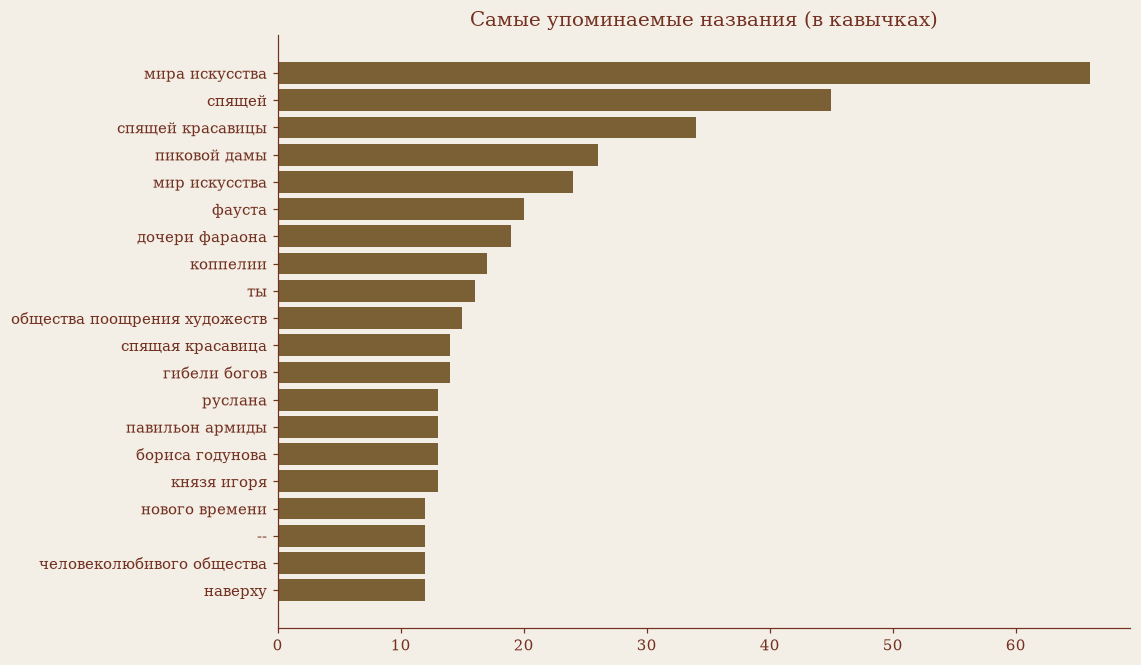

In [136]:
titles = Counter()
for t in df['text']:
    for m in re.findall(r'["«“‘’]([^"»”’]{2,40})["»”’]', str(t)):
        titles[m.strip().lower()] += 1

top = titles.most_common(20)
plt.figure(figsize=(10, 7))
plt.barh([t for t, _ in top][::-1], [c for _, c in top][::-1], color='#7C6035')
plt.title('Самые упоминаемые названия (в кавычках)')
plt.show()

Для выявления художественного и театрального репертуара, упоминаемого Бенуа, регулярным выражением извлекались все фрагменты, заключенные в кавычки. С большим отрывом лидирует «Мир искусства» — это и журнал, и художественное объединение, смысловой центр всей профессиональной деятельности автора. Далее следует балетно-оперный репертуар, в оформлении и обсуждении которого Бенуа принимал участие: «Спящая красавица», «Пиковая дама», «Фауст», «Дочь фараона», «Коппелия», «Гибель богов», «Руслан», «Павильон Армиды», «Борис Годунов», «Князь Игорь», а также названия художественных институций («Общество поощрения художеств», «Новое время»). 

Метод заметно зашумлен: во-первых, кавычки выделяют не только названия, но и обычные слова в прямой речи или с логическим ударением («ты», «наверху», артефакт «--»); во-вторых, одно название попадает в список в разных падежных формах («Спящей» / «Спящей красавицы» / «Спящая красавица»), поскольку содержимое кавычек, в отличие от остального текста, не лемматизировалось. Эти искажения отсеиваются при ручном просмотре, но их наличие является ограничением быстрого извлечения по формальному признаку кавычек.

## Выводы

Проведенный количественный анализ пяти книг «Моих воспоминаний» Александра Бенуа позволяет сделать главный вывод о том, что в мемуарах четко разделяются переменные характеристики, откликающиеся на ход биографии автора, и постоянные, образующие устойчивый авторский идиолект.

К переменным сигналам относятся лексика, круг лиц, география и иноязычные вкрапления. Все они согласованно фиксируют единую траекторию — «движение наружу», расширение мира автора от замкнутого пространства семьи к европейскому художественному авангарду.

К инвариантным характеристикам относятся грамматический профиль (доли частей речи совпадают по книгам вплоть до сотых), синтаксический ритм (стабильная длина предложения 25–28 слов) и эмоциональный фон (ровное преобладание доверия, ожидания и радости во всех книгах). Эти признаки не реагируют на смену темы и периода, подтверждая индивидуальный стиль автора.

Дальнейшие шаги исследования включают разрешение кореференции прозвищ и фамилий для уточнения графа, а также сопоставление вербального автопортрета Бенуа с визуальным — методами компьютерного зрения его живописных и театральных работ. 